# Diabetes Prediction Project

**Dataset:** Diabetes Health Indicators (BRFSS 2015)  
**Goal:** Predict whether a patient has diabetes (binary classification) based on health indicators.  
**Model:** Multi-Layer Perceptron (MLP)


## 1. Loading & First Look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/diabetes_012_health_indicators_BRFSS2015.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [3]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


**Observations:**
- 253,680 rows and 22 columns
- All columns are `float64` — we will cast them to appropriate types during cleaning
- The target column is `Diabetes_012` with values 0 (no diabetes), 1 (pre-diabetes), 2 (diabetes)
- No null values in the dataset


## 2. Cleaning

### 2.1 Binarizing the Target Variable

The original target `Diabetes_012` has three classes: 0 (no diabetes), 1 (pre-diabetes), 2 (diabetes).  
We simplify this into a binary classification problem: **0 = no diabetes, 1 = diabetes** (class 2 → 1, others → 0).  
This makes the problem cleaner and more clinically meaningful.


In [4]:
df["Diabetes"] = df["Diabetes_012"].map(lambda x: 1.0 if x == 2.0 else 0.0)
df.drop(columns=["Diabetes_012"], inplace=True)
df["Diabetes"].value_counts()

Diabetes
0.0    218334
1.0     35346
Name: count, dtype: int64

### 2.2 Null Values & Duplicates

In [5]:
print(f"Null values: {df.isnull().sum().sum()}")
print(f"Duplicated rows: {df.duplicated().sum()}")

Null values: 0
Duplicated rows: 24206


No null values in this dataset. There are duplicated rows which we drop to avoid bias during training.

In [6]:
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f"Remaining rows after deduplication: {len(df)}")

Remaining rows after deduplication: 229474


### 2.3 Typing Variables

All columns are currently `float64`. We cast:
- Binary columns (0/1) → `bool`
- Ordinal/scale columns → `int`
- `BMI` stays as `float64` (continuous)


In [7]:
binary_cols = [
    "Diabetes", "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex",
]
int_cols = ["GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]

df[binary_cols] = df[binary_cols].astype(bool)
df[int_cols] = df[int_cols].astype(int)
df.dtypes

HighBP                     bool
HighChol                   bool
CholCheck                  bool
BMI                     float64
Smoker                     bool
Stroke                     bool
HeartDiseaseorAttack       bool
PhysActivity               bool
Fruits                     bool
Veggies                    bool
HvyAlcoholConsump          bool
AnyHealthcare              bool
NoDocbcCost                bool
GenHlth                   int64
MentHlth                  int64
PhysHlth                  int64
DiffWalk                   bool
Sex                        bool
Age                       int64
Education                 int64
Income                    int64
Diabetes                   bool
dtype: object

### 2.4 Outlier Removal (BMI)

`BMI` is the only truly continuous and unbounded column. All other columns are binary or bounded ordinal scales where outliers are not meaningful.  
We use the IQR method to remove BMI outliers.


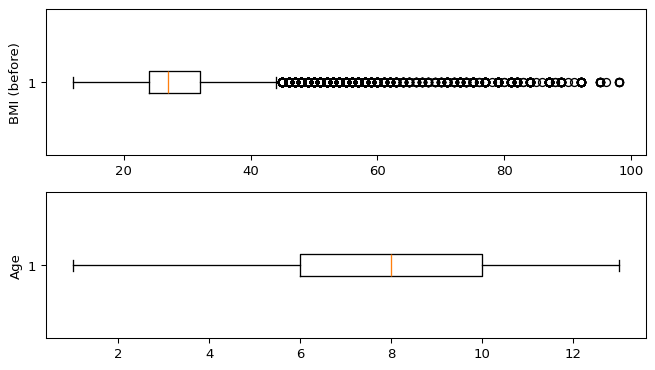

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(7, 4), dpi=95)
axs[0].boxplot(df["BMI"], vert=False)
axs[0].set_ylabel("BMI (before)")
axs[1].boxplot(df["Age"], vert=False)
axs[1].set_ylabel("Age")
plt.tight_layout()
plt.show()

In [9]:
q1, q3 = np.percentile(df["BMI"], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df_clean = df[(df["BMI"] >= lower) & (df["BMI"] <= upper)]
print(f"Rows before: {len(df)}, after: {len(df_clean)}, removed: {len(df) - len(df_clean)}")

Rows before: 229474, after: 223836, removed: 5638


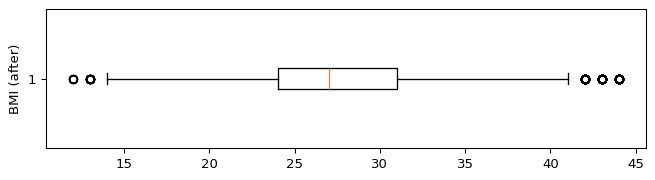

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(7, 2), dpi=95)
axs.boxplot(df_clean["BMI"], vert=False)
axs.set_ylabel("BMI (after)")
plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

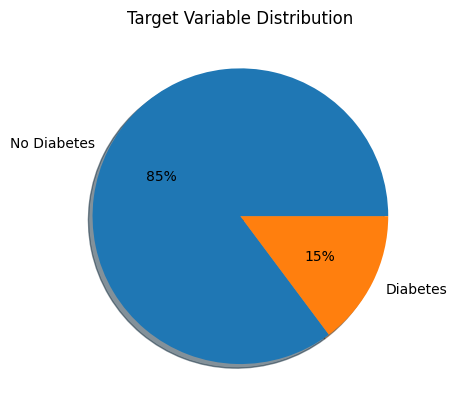

In [11]:
plt.pie(
    df_clean["Diabetes"].value_counts(),
    labels=["No Diabetes", "Diabetes"],
    autopct="%.f%%",
    shadow=True,
)
plt.title("Target Variable Distribution")
plt.show()

**Observation:** The dataset is heavily imbalanced — approximately **86% no diabetes vs 14% diabetes**.  
This class imbalance will affect model training. Strategies to consider:
- Oversampling the minority class (SMOTE)
- Using class weights in the loss function
- Evaluating with F1-score / AUC-ROC rather than accuracy alone


### 3.2 Correlation with Target

In [12]:
corr = df_clean.corr()
print(corr["Diabetes"].sort_values(ascending=False))

Diabetes                1.000000
GenHlth                 0.268992
HighBP                  0.249408
BMI                     0.210507
DiffWalk                0.193075
HighChol                0.191624
Age                     0.180645
HeartDiseaseorAttack    0.167779
PhysHlth                0.146730
Stroke                  0.098966
CholCheck               0.071424
MentHlth                0.047079
Smoker                  0.046617
Sex                     0.037888
AnyHealthcare           0.026207
NoDocbcCost             0.017155
Fruits                 -0.022817
Veggies                -0.040768
HvyAlcoholConsump      -0.064803
PhysActivity           -0.093129
Education              -0.099782
Income                 -0.134114
Name: Diabetes, dtype: float64


**Observations:**
- The strongest positive correlations with Diabetes are: `GenHlth` (0.27), `HighBP` (0.25), `BMI` (0.21), `DiffWalk` (0.19)
- The strongest negative correlations are: `Income` (-0.13), `Education` (-0.10), `PhysActivity` (-0.09)
- All correlations are relatively low, suggesting non-linear relationships — which motivates the use of an MLP over logistic regression
- No feature was dropped based on correlation alone, as non-linear models can extract value from weakly correlated features


### 3.3 Correlation Heatmap

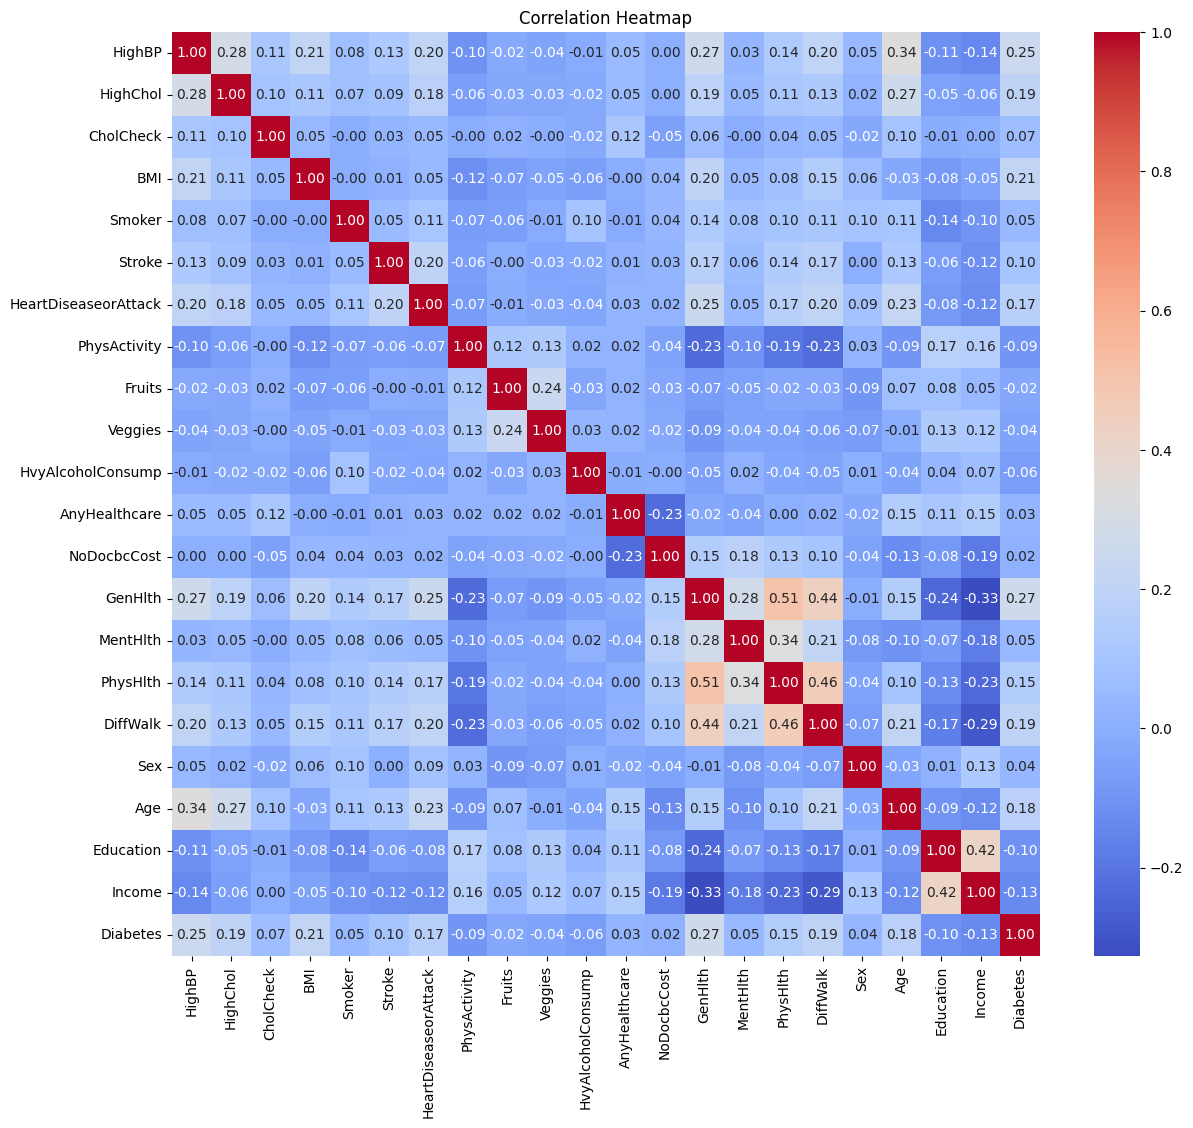

In [13]:
plt.figure(figsize=(14, 12), dpi=100)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** No pair of features shows very high inter-correlation (multicollinearity), so we keep all features.

## 4. Preprocessing

### 4.1 Train / Validation / Test Split

We use an **80/10/10 split**:
- 80% training (~179k samples) — used to train the model
- 10% validation (~22k samples) — used to tune hyperparameters
- 10% test (~22k samples) — used for final evaluation only

With 223k samples, 10% is still ~22k rows which is sufficient for reliable evaluation.


In [14]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Diabetes"])
y = df_clean["Diabetes"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 179068 samples
Val:   22384 samples
Test:  22384 samples


### 4.2 Normalization

We apply **StandardScaler** (zero mean, unit variance) to the feature sets.  
Important: the scaler is **fit only on training data** and then applied to val/test — fitting on val/test would leak information about their distribution into the model.


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")

Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0000


## 5. Conclusions & Next Steps

### Key findings from EDA:
- The dataset is **clean** (no nulls) but **imbalanced** (86/14 split)
- `GenHlth`, `HighBP`, `BMI`, and `DiffWalk` are the strongest predictors of diabetes
- Correlations are low overall, suggesting non-linear relationships in the data

### Why MLP?
- Linear models (logistic regression) may underfit given the low linear correlations
- An MLP can capture non-linear feature interactions
- The dataset is large enough (~180k training samples) to train a neural network effectively

### Next steps:
1. Handle class imbalance (class weights or SMOTE)
2. Design and train the MLP architecture
3. Tune hyperparameters using the validation set
4. Evaluate final performance on the test set using F1-score and AUC-ROC


## 6. Model Architecture

### 6.1 Choice of Architecture

We use a **Multi-Layer Perceptron (MLP)** for this binary classification task. This choice is motivated by:
- Linear correlations between features and the target are low (max 0.27), suggesting non-linear relationships that a neural network can capture better than logistic regression
- The dataset is large enough (~180k training samples) to train a neural network effectively
- MLPs are well-suited for tabular data with mixed feature types


### 6.2 Architecture Design

The network follows a **funnel architecture**: the number of neurons decreases layer by layer, progressively compressing information toward the final binary decision.

```
Input (21 features)
    ↓
Dense(64) + ReLU
    ↓
Dense(32) + ReLU
    ↓
Dense(1) + Sigmoid → probability of diabetes
```

**Design choices:**
- **ReLU** for hidden layers: avoids the vanishing gradient problem that affects Sigmoid in deep networks. For positive inputs, gradient is always 1, allowing efficient backpropagation
- **Sigmoid** for output: squashes the output to [0, 1], interpretable as a probability
- **Funnel shape (64→32)**: forces the network to learn compressed, generalized representations rather than memorizing training data
- **Binary Cross-Entropy** loss: standard for binary classification, penalizes confident wrong predictions logarithmically
- **Adam** optimizer: combines momentum and adaptive learning rates per parameter, converges faster than plain SGD without requiring manual learning rate tuning


### 6.3 Model Summary (Dropout variant)

In [16]:
from keras import Sequential
from keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(21,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

### 6.4 Handling Class Imbalance

The dataset is heavily imbalanced (86% no diabetes / 14% diabetes). Without correction, the model learns to always predict the majority class, achieving ~86% accuracy while detecting no diabetes cases.

We address this using **class weights** — the loss function penalizes mistakes on the minority class more heavily:

$$w_i = \frac{n_{samples}}{n_{classes} \times n_{samples_i}}$$

With ~14% positive class, the diabetes weight is approximately **3x** higher than the no-diabetes weight, forcing the model to focus on correctly identifying diabetes cases.


### 6.5 Regularization

We tested three architectural variants to prevent overfitting:

| Model | Layers | Val Loss | Val Recall | Val Precision | Params |
|-------|--------|----------|------------|---------------|--------|
| Base | Dense → Dense → Output | 0.517 | 0.76 | 0.30 | 3,521 |
| Dropout (0.3) | Dense → Dropout → Dense → Dropout → Output | 0.513 | 0.78 | 0.30 | 3,521 |
| Complete (Dropout + BatchNorm + L2) | Dense → BN → Dropout → Dense → BN → Dropout → Output | 0.528 | 0.76 | 0.30 | 3,905 |

**Observations:**
- Training and validation metrics are very close across all variants, indicating the model is **not overfitting** significantly
- **Dropout** provides a marginal improvement in val loss (0.513 vs 0.517) and recall (0.78 vs 0.76)
- The **complete model** adds complexity without improving results — stacking Dropout, BatchNormalization, and L2 over-regularizes this relatively shallow network
- **Dropout is selected as the best baseline** for Sprint 3

**Early stopping** (patience=10) was used to prevent overfitting, automatically restoring the best weights.


### 6.6 Limitations & Sprint 3 Outlook

Precision is stuck at **~0.30** across all variants, meaning 7 out of 10 positive predictions are false positives. This is a known limitation of the current setup:

1. **Class imbalance** — class weights shift the model toward higher recall at the cost of precision. Sprint 3 will explore **SMOTE** (Synthetic Minority Oversampling Technique) as an alternative
2. **Decision threshold** — the default 0.5 threshold is suboptimal for imbalanced data. Sprint 3 will include **threshold analysis** (ROC curve, precision-recall curve) to find a better operating point
3. **Architecture** — Sprint 3 will explore deeper networks and different hyperparameter combinations
4. **Explainability** — Sprint 3 will add SHAP values to understand which features drive predictions


## 7. Model optimization

### 7.1 Decision Threshold Analysis

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tensorflow.keras.models import load_model

model = load_model("best-model.keras")

y_pred_proba = model.predict(X_val_scaled).ravel()

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_pred_proba >= t).astype(int)
    
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    
    results.append((t, precision, recall, f1, acc))

for r in results:
    print(f"Threshold={r[0]:.2f} | Precision={r[1]:.3f} | Recall={r[2]:.3f} | F1={r[3]:.3f} | Acc={r[4]:.3f}")

700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step
[0.61364424 0.01432189 0.06865574 ... 0.49069786 0.12468882 0.11236317]
Threshold=0.10 | Precision=0.183 | Recall=0.984 | F1=0.309 | Acc=0.362
Threshold=0.15 | Precision=0.199 | Recall=0.969 | F1=0.330 | Acc=0.432
Threshold=0.20 | Precision=0.213 | Recall=0.948 | F1=0.348 | Acc=0.487
Threshold=0.25 | Precision=0.228 | Recall=0.927 | F1=0.366 | Acc=0.536
Threshold=0.30 | Precision=0.242 | Recall=0.900 | F1=0.382 | Acc=0.579
Threshold=0.35 | Precision=0.256 | Recall=0.870 | F1=0.396 | Acc=0.616
Threshold=0.40 | Precision=0.270 | Recall=0.833 | F1=0.408 | Acc=0.650
Threshold=0.45 | Precision=0.288 | Recall=0.795 | F1=0.423 | Acc=0.686
Threshold=0.50 | Precision=0.307 | Recall=0.748 | F1=0.436 | Acc=0.719
Threshold=0.55 | Precision=0.333 | Recall=0.700 | F1=0.451 | Acc=0.753
Threshold=0.60 | Precision=0.356 | Recall=0.628 | F1=0.454 | Acc=0.782
Threshold=0.65 | Precision=0.386 | Recall=0.540 | F1=0.450 | Acc=0.809
Threshold=0.70 | Precision=0.412 